# 🛰️ Semantic Search — Satellite Tiles (CLIP + FAISS)

**Cities:** Indore, Mumbai, Delhi, Bengaluru, Ahmedabad
**Input:** tiles from Member 2's pipeline (`dataset/tiles/<City>/<year>/<tile_id>.tif`)
**Output:** a FAISS search index + a `search()` function that takes a text query and returns matching tiles

**Instructions:** Runtime → Change runtime type → GPU (T4) → Save, then run cells top to bottom.

This is a cleaned-up version: builds the index once, saves it, and searches it. No live-patching of API files, no restarting servers — just the AI/ML part.

## Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Set dataset path

⚠️ Edit `base_path` below if your Drive folder structure is different.

In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles")

assert base_path.exists(), f"Path not found: {base_path} — check the folder in your Drive"

cities = sorted([f.name for f in base_path.iterdir() if f.is_dir()])
print("Cities found:", cities)

for city in cities:
    city_path = base_path / city
    years = sorted([f.name for f in city_path.iterdir() if f.is_dir()])
    print(f"  {city}: years = {years}")

Cities found: ['Ahmedabad', 'Bengaluru', 'Delhi', 'Indore', 'Mumbai']
  Ahmedabad: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Bengaluru: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Delhi: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Indore: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Mumbai: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']


## Step 3 — Install required libraries

In [ ]:
!pip install -q open_clip_torch torch torchvision faiss-cpu rasterio matplotlib pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


## Step 4 — Load CLIP model

In [ ]:
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model = model.to(device).eval()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

print("CLIP model loaded ✅")

Using device: cuda


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP model loaded ✅


## Step 5 — Helper function: tile `.tif` → RGB image

Our tiles have bands in this order: `B02, B03, B04, B08, B11, B12, valid`
(Blue, Green, Red, NIR, SWIR1, SWIR2, valid-mask).
For a true-colour RGB image we need Red=B04, Green=B03, Blue=B02 → that's bands at index 2, 1, 0.

In [ ]:
import rasterio
import numpy as np
from PIL import Image

def tif_to_pil(path):
    """Read a tile .tif and return a true-colour RGB PIL image for CLIP."""
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
        if img.shape[0] >= 3:
            rgb = np.dstack((img[2], img[1], img[0]))   # R=B04, G=B03, B=B02
        else:
            band = img[0]
            rgb = np.dstack((band, band, band))
        rgb = rgb / (rgb.max() + 1e-6) * 255
        rgb = rgb.astype(np.uint8)
    return Image.fromarray(rgb)

def load_tile(city, year, tile_name):
    """Convenience loader: load_tile('Indore', '2022', 'Indore_r05_c12.tif') -> numpy RGB array"""
    path = base_path / city / str(year) / tile_name
    return np.array(tif_to_pil(path))

print("Helper functions ready ✅")

Helper functions ready ✅


## Step 6 — Generate embeddings for ALL cities + build one FAISS index

Processes every tile from every city. This is the longest step
(roughly 10-20 min depending on total tile count, faster with GPU).

The index is **saved to Drive** at the end, so you only need to run this once —
next time just load the saved index (Step 6B) instead of rebuilding.

In [ ]:
import faiss
import pickle

all_tif_files = sorted(list(base_path.rglob("*.tif")) + list(base_path.rglob("*.tiff")))
print("Total TIFF files across all cities:", len(all_tif_files))

embeddings = []
valid_paths = []

with torch.no_grad():
    for i, path in enumerate(all_tif_files):
        try:
            pil_img = tif_to_pil(path)
            img_tensor = preprocess(pil_img).unsqueeze(0).to(device)
            emb = model.encode_image(img_tensor)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            embeddings.append(emb.cpu().numpy().astype("float32")[0])
            valid_paths.append(str(path))
        except Exception as e:
            print(f"  skipped {path.name}: {e}")

        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1}/{len(all_tif_files)}")

embeddings = np.stack(embeddings).astype("float32")
print(f"\nEmbeddings shape: {embeddings.shape}")

# Build a cosine-similarity FAISS index (vectors are already L2-normalised above)
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
print(f"FAISS index built with {index.ntotal} vectors ✅")

Total TIFF files across all cities: 2240
  processed 100/2240
  processed 200/2240
  processed 300/2240
  processed 400/2240
  processed 500/2240
  processed 600/2240
  processed 700/2240
  processed 800/2240
  processed 900/2240
  processed 1000/2240
  processed 1100/2240
  processed 1200/2240
  processed 1300/2240
  processed 1400/2240
  processed 1500/2240
  processed 1600/2240
  processed 1700/2240
  processed 1800/2240
  processed 1900/2240
  processed 2000/2240
  processed 2100/2240
  processed 2200/2240

Embeddings shape: (2240, 512)
FAISS index built with 2240 vectors ✅


## Step 6B — Save the index to Drive (so you never have to rebuild it)

In [ ]:
INDEX_DIR = Path("/content/drive/MyDrive/satellite_search_index")
INDEX_DIR.mkdir(parents=True, exist_ok=True)

np.save(INDEX_DIR / "embeddings.npy", embeddings)
with open(INDEX_DIR / "paths.pkl", "wb") as f:
    pickle.dump(valid_paths, f)
faiss.write_index(index, str(INDEX_DIR / "faiss.index"))

print(f"Saved index to {INDEX_DIR} ✅")
print("Next time, skip Step 6 and just run Step 6C to reload it instantly.")

Saved index to /content/drive/MyDrive/satellite_search_index ✅
Next time, skip Step 6 and just run Step 6C to reload it instantly.


## Step 6C — (Optional, next time) Load a previously saved index instead of rebuilding

In [ ]:
# Run this INSTEAD of Step 6 if you already built and saved the index before.

# INDEX_DIR = Path("/content/drive/MyDrive/satellite_search_index")
# embeddings = np.load(INDEX_DIR / "embeddings.npy")
# with open(INDEX_DIR / "paths.pkl", "rb") as f:
#     valid_paths = pickle.load(f)
# index = faiss.read_index(str(INDEX_DIR / "faiss.index"))
# print(f"Loaded {index.ntotal} vectors from {INDEX_DIR} ✅")

## Step 7 — Semantic search function (works across all cities)

In [ ]:
import matplotlib.pyplot as plt

def search_similar(query_text, top_k=5, show=True):
    """Text query -> list of matching tiles, sorted by similarity. Optionally plots them."""
    text_tokens = tokenizer([query_text]).to(device)
    with torch.no_grad():
        text_emb = model.encode_text(text_tokens)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    text_emb = text_emb.cpu().numpy().astype("float32")

    scores, indices = index.search(text_emb, top_k)

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        if idx < 0:
            continue
        p = Path(valid_paths[idx])
        results.append({
            "rank": rank,
            "score": float(score),
            "path": str(p),
            "tile_id": p.stem,
            "year": p.parent.name,
            "city": p.parent.parent.name,
        })

    if show:
        fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
        if len(results) == 1:
            axes = [axes]
        for ax, r in zip(axes, results):
            img = tif_to_pil(r["path"])
            ax.imshow(img)
            ax.set_title(f"{r['city']} {r['year']}\n{r['tile_id']}\nscore={r['score']:.3f}", fontsize=9)
            ax.axis("off")
        fig.suptitle(f'Query: "{query_text}"')
        fig.tight_layout()
        plt.show()

    return results

print("search_similar() ready ✅")

search_similar() ready ✅


### Try a few searches (across all cities)

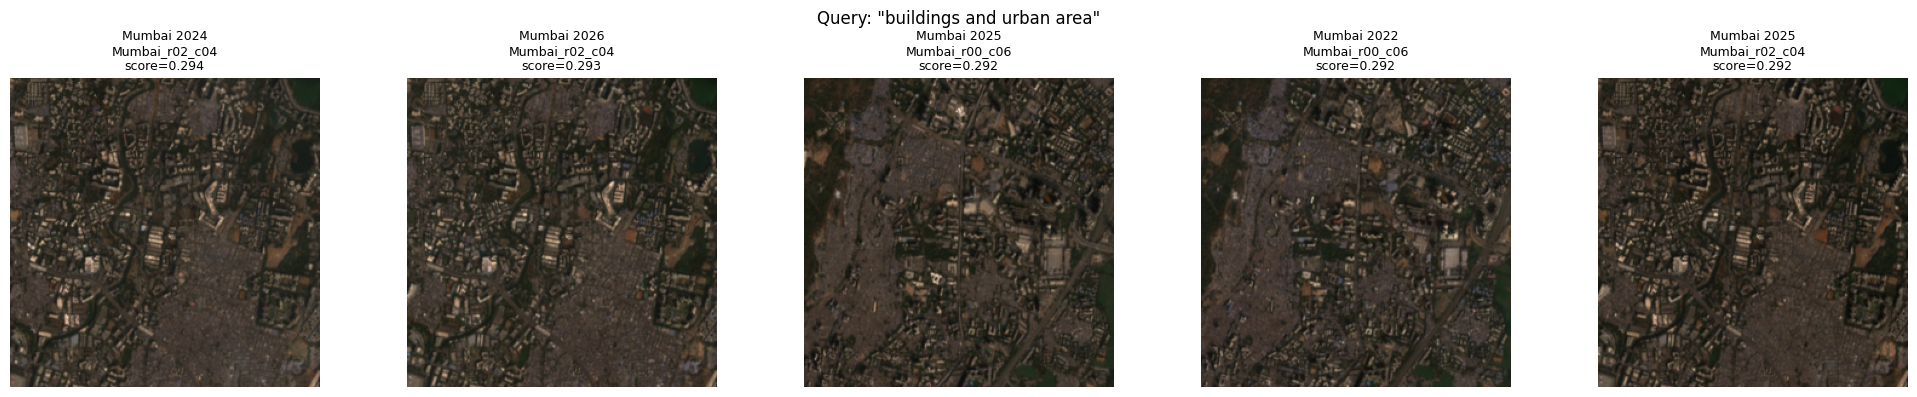

In [ ]:
results = search_similar("buildings and urban area", top_k=5)

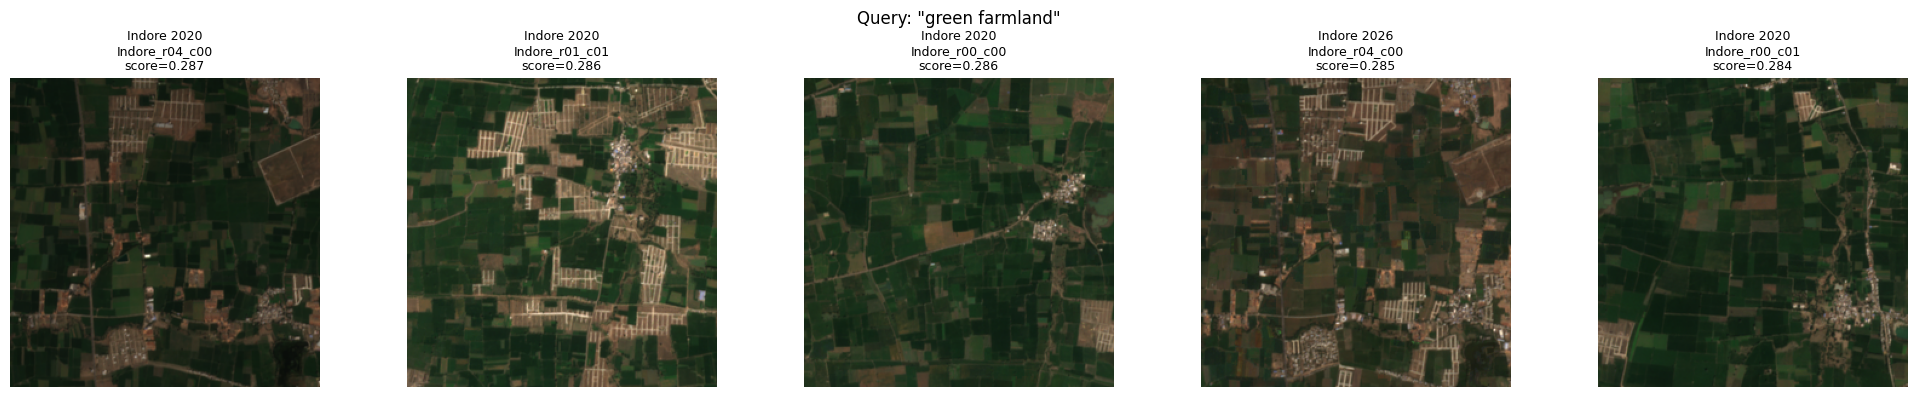

In [ ]:
results = search_similar("green farmland", top_k=5)

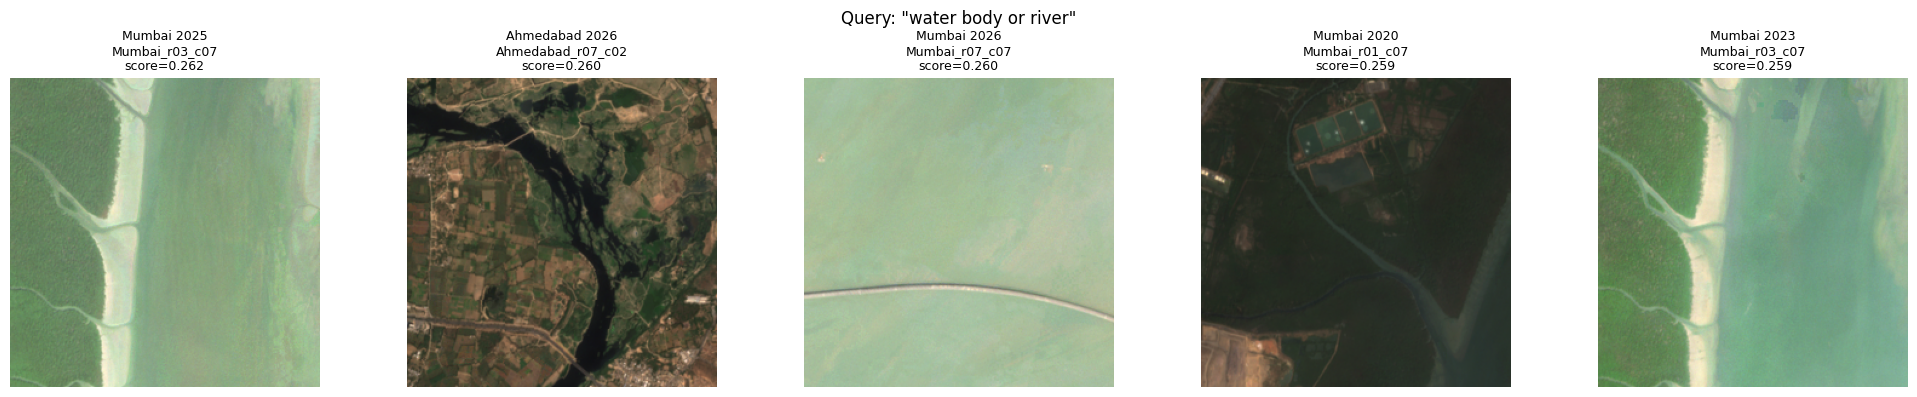

In [ ]:
results = search_similar("water body or river", top_k=5)

## Step 8 — Export search results as JSON (for the backend team)

This is the format Member 4 (backend) can plug straight into an API response.

In [ ]:
import json

def search_to_json(query_text, top_k=5):
    results = search_similar(query_text, top_k=top_k, show=False)
    return json.dumps({"query": query_text, "total_results": len(results), "results": results}, indent=2)

print(search_to_json("construction site", top_k=3))

{
  "query": "construction site",
  "total_results": 3,
  "results": [
    {
      "rank": 1,
      "score": 0.24156241118907928,
      "path": "/content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Mumbai/2020/Mumbai_r06_c05.tif",
      "tile_id": "Mumbai_r06_c05",
      "year": "2020",
      "city": "Mumbai"
    },
    {
      "rank": 2,
      "score": 0.24068517982959747,
      "path": "/content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Mumbai/2021/Mumbai_r06_c05.tif",
      "tile_id": "Mumbai_r06_c05",
      "year": "2021",
      "city": "Mumbai"
    },
    {
      "rank": 3,
      "score": 0.23738959431648254,
      "path": "/content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Indore/2023/Indore_r03_c01.tif",
      "tile_id": "Indore_r03_c01",
      "year": "2023",
      "city": "Indore"
    }
  ]
}
